# Anomaly detection with autoencoders

The goal of this activity is to use a convolutional encoder to do unsupervised anomaly detection on images. An autoencoder can be trained on a set of images (say all of the 'animal' classes from CIFAR-10), and then used to detect images which do not belong in this 'class' e.g. boats by looking at the reconstruction error. Images which are very different from the training set will not be represented well in latent space and will therefore suffer in reconstruction quality.

Most of the up front data wrangling has been done for you, your job it to adapt the autoencoder architecture from the compression and denoising notebooks to anomaly detection.

## 1. Notebook setup

### 1.1. Imports

In [55]:
import json
import os
import pickle
from dotenv import load_dotenv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf

from keras import Model, Layer, callbacks, optimizers
from keras.layers import (
    Input, Conv2D, Conv2DTranspose, BatchNormalization,
    LeakyReLU, Flatten, Dense, Reshape, MaxPool2D
)
from keras import ops
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

# Reproducibility
tf.random.set_seed(315)
np.random.seed(315)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.16.1
GPU available: True


### 1.2. GPU configuration

In [ ]:
# Select GPU and configure memory growth to avoid allocation issues
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)

        print('Using GPU with memory growth enabled')

    except RuntimeError as e:
        print(f'GPU configuration error: {e}')

Using GPU with memory growth enabled


### 1.3. Environment configuration

In [57]:
# Environment variables
project_root = Path('..').resolve()
load_dotenv(project_root / '.env')

# Paths
data_path = project_root / 'data'

print(f'Data will be cached to: {data_path}')

Data will be cached to: /workspaces/autoencoders/data


### 1.4. Hyperparameters

In [ ]:
# Set False to skip training and load saved model
train_linear_bottleneck = True
train_conv_bottleneck   = True
train_var_bottleneck    = True

image_size   = 32    # Image input size (32x32)
val_split    = 0.1
loss         = 'mae'
batch_size   = 16
lr           = 1e-4
lr_decay     = 0.5
lr_patience  = 5
min_lr       = 1e-7
epochs       = 1000
verbose      = 0

early_stopping_patience = 10
early_stopping_min_delta = 0.0005

cifar10_classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck',
]

## 2. Data preparation

### 2.1. Download and extract CIFAR10

In [59]:
# Download and extract
archive_path = tf.keras.utils.get_file(
    fname='cifar-10-python.tar.gz',
    origin='https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz',
    cache_dir=data_path,
    extract=True,
    archive_format='auto'
)

### 2.2. Load CIFAR-10 from disk

In [60]:
def load_cifar_batch(file_path):
    '''Helper function to load a single CIFAR-10 batch from disk.
    Returns the data and labels as numpy arrays.
    '''

    with open(file_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    
    data = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(batch[b'labels'])

    return data, labels

In [61]:
# Load the dataset
data_dir = os.path.join(os.path.dirname(archive_path), 'cifar-10-batches-py')

# Load training splits
x_train_list, y_train_list = [], []

for i in range(1, 6):
    x_b, y_b = load_cifar_batch(os.path.join(data_dir, f'data_batch_{i}'))
    x_train_list.append(x_b)
    y_train_list.append(y_b)

x_train = np.concatenate(x_train_list)
y_train = np.concatenate(y_train_list)

# Load test split
x_test, y_test = load_cifar_batch(os.path.join(data_dir, 'test_batch'))

print(f'Training images shape: {x_train.shape}, Training labels shape: {y_train.shape}')
print(f'Test images shape: {x_test.shape}, Test labels shape: {y_test.shape}')

Training images shape: (50000, 32, 32, 3), Training labels shape: (50000,)
Test images shape: (10000, 32, 32, 3), Test labels shape: (10000,)


### 2.3. Inspect

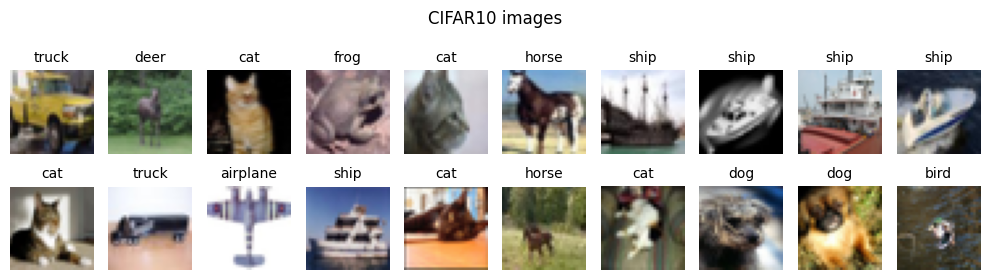

In [62]:
# Randomly select 10 indices from the training set
sample_indices = np.random.choice(len(x_train), size=20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(10, 3))
axes = axes.flatten()

fig.suptitle('CIFAR10 images')

for idx, ax in zip(sample_indices, axes):
  img = x_train[idx]  # Values are in [0, 1]
  label_idx = y_train[idx][0] if y_train.ndim > 1 else y_train[idx]

  ax.imshow(img)
  ax.set_title(cifar10_classes[label_idx], fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

### 2.4. Select only 'animal' images for training set

In [63]:
# Target animal classes: cat (3), deer (4), dog (5), horse (7)
animal_classes = [3, 4, 5, 7]

# Flatten labels if shape is (N, 1)
y_flat = y_train.flatten() if y_train.ndim > 1 else y_train

# Create boolean mask
mask = np.isin(y_flat, animal_classes)

# Filter and normalize
x_train_normals = x_train[mask].astype('float32') / 255.0
y_train_normals = y_flat[mask]

print(f"Filtered training normals shape: {x_train_normals.shape}")
print(f"Unique classes present: {np.unique(y_train_normals)}")

Filtered training normals shape: (20000, 32, 32, 3)
Unique classes present: [3 4 5 7]


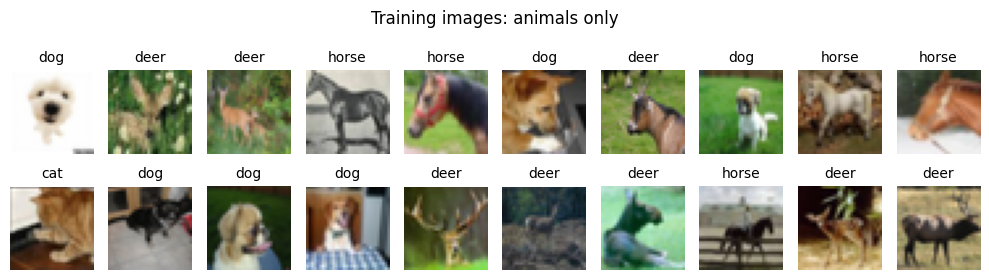

In [64]:
# Randomly select 10 indices from the training set
sample_indices = np.random.choice(len(x_train_normals), size=20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(10, 3))
axes = axes.flatten()

fig.suptitle('Training images: animals only')

for idx, ax in zip(sample_indices, axes):
  img = x_train_normals[idx]  # Values are in [0, 1]
  label_idx = y_train_normals[idx]

  ax.imshow(img)
  ax.set_title(cifar10_classes[label_idx], fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

### 2.5. Select 'animal' + car and truck ('anomaly') images for test set

In [65]:
# Target test classes: 4 normals (3, 4, 5, 7) + 2 anomalies/vehicles (1, 9)
target_test_classes = [3, 4, 5, 7, 1, 9]
normal_classes = {3, 4, 5, 7}

y_test_flat = y_test.flatten() if y_test.ndim > 1 else y_test
test_mask = np.isin(y_test_flat, target_test_classes)

# Filter and scale test subset
x_test_subset = x_test[test_mask].astype("float32") / 255.0
y_test_subset = y_test_flat[test_mask]

# Ground-truth binary labels: 0 = normal (animal), 1 = anomaly (vehicle)
is_normal = np.isin(y_test_subset, list(normal_classes))
y_test_binary = (~is_normal).astype(int)

print(f"Filtered test subset shape: {x_test_subset.shape}")
print(f"Normal animals: {np.sum(y_test_binary == 0)}")
print(f"Vehicle anomalies (auto/truck): {np.sum(y_test_binary == 1)}")

Filtered test subset shape: (6000, 32, 32, 3)
Normal animals: 4000
Vehicle anomalies (auto/truck): 2000


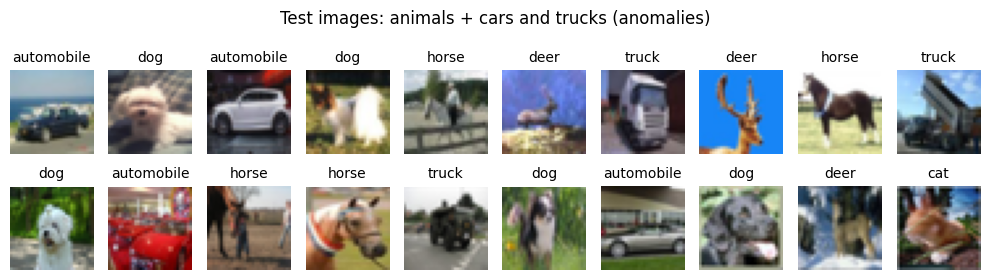

In [66]:
# Randomly select 10 indices from the test set
sample_indices = np.random.choice(len(x_test_subset), size=20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(10, 3))
axes = axes.flatten()

fig.suptitle('Test images: animals + cars and trucks (anomalies)')

for idx, ax in zip(sample_indices, axes):
  img = x_test_subset[idx]  # Values are in [0, 1]
  label_idx = y_test_subset[idx]

  ax.imshow(img)
  ax.set_title(cifar10_classes[label_idx], fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Linear bottleneck model

### 3.1. Output paths

In [67]:
# Paths
model_path   = project_root / 'models' / 'anomaly_linear_bottleneck.keras'
history_path = project_root / 'logs' / 'anomaly_linear_bottleneck' / 'history.json'
log_dir      = project_root / 'logs' / 'anomaly_linear_bottleneck'

log_dir.mkdir(parents=True, exist_ok=True)

print(f'Data will be cached to: {data_path}')
print(f'Model will be saved to: {model_path}')
print(f'History will be saved to: {history_path}')
print(f'Log directory: {log_dir}')

Data will be cached to: /workspaces/autoencoders/data
Model will be saved to: /workspaces/autoencoders/models/anomaly_linear_bottleneck.keras
History will be saved to: /workspaces/autoencoders/logs/anomaly_linear_bottleneck/history.json
Log directory: /workspaces/autoencoders/logs/anomaly_linear_bottleneck


### 3.2. Model definition

In [68]:
def build_linear_bottleneck_model(input_shape=(32, 32, 3), latent_dim=192):
    '''Builds a convolutional autoencoder with a linear bottleneck and 
    the specified input shape and latent dimension.'''

    # Build the encoder
    encoder_inputs = Input(shape=input_shape)
    x = encoder_inputs
    
    # Encoder (32x32x3 -> 16x16x64)
    x = Conv2D(32, 3, padding='same', strides=2, name='enc_conv1')(x)
    x = BatchNormalization(name='enc_bn1')(x)
    x = LeakyReLU(0.2, name='enc_relu1')(x)

    x = Conv2D(64, 3, padding='same', strides=2)(x)
    x = BatchNormalization(name='enc_bn2')(x)
    x = LeakyReLU(0.2, name='enc_relu2')(x)

    # Bottleneck: 16x16x64 = 16384 -> latent dim
    x = Flatten(name='enc_flatten')(x)
    latent = Dense(latent_dim, activation='relu', name='latent')(x)
    encoder = Model(encoder_inputs, latent, name='encoder')

    # Build the decoder
    decoder_input = Input(shape=(latent_dim,), name='latent_input')
    x = decoder_input

    # Project and reshape: latent_dim -> 2048
    x = Dense(16 * 16 * 64, activation='relu', name='dec_dense')(x)
    x = Reshape((16, 16, 64), name='dec_reshape')(x)

    # Decoder (16x16x64 -> 32x32x3)
    x = Conv2DTranspose(64, 3, padding='same', strides=2, name='dec_conv1a')(x)
    x = BatchNormalization(name='dec_bn1a')(x)
    x = LeakyReLU(0.2, name='dec_relu1a')(x)
    x = Conv2D(64, 3, padding='same', name='dec_conv1b')(x)
    x = BatchNormalization(name='dec_bn1b')(x)
    x = LeakyReLU(0.2, name='dec_relu1b')(x)

    x = Conv2DTranspose(32, 3, padding='same', strides=2, name='dec_conv2a')(x)
    x = BatchNormalization(name='dec_bn2a')(x)
    x = LeakyReLU(0.2, name='dec_relu2a')(x)
    x = Conv2D(32, 3, padding='same', name='dec_conv2b')(x)
    x = BatchNormalization(name='dec_bn2b')(x)
    x = LeakyReLU(0.2, name='dec_relu2b')(x)
    x = MaxPool2D(pool_size=2, name='max_pool')(x)

    # Final output 32x32x32 -> 32x32x3 
    reconstructed = Conv2D(3, 3, padding='same', activation='sigmoid', name='output_image')(x)
    decoder = Model(decoder_input, reconstructed, name='decoder')

    # Full autoencoder: input -> encoder -> decoder -> reconstructed output
    ae_output = decoder(encoder(encoder_inputs))
    autoencoder = Model(encoder_inputs, ae_output, name='autoencoder')
    
    return autoencoder, encoder, decoder


In [69]:
# Build the model
autoencoder, encoder, decoder = build_linear_bottleneck_model()

if train_linear_bottleneck:

    # Compile naive model for training
    autoencoder.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=loss
    )

else:

    # Load the pre-trained weights
    autoencoder.load_weights(str(model_path).replace('.keras', '_weights.weights.h5'))

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 192)            │       806,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 32, 32, 3)      │     3,265,315 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,071,715 (15.53 MB)

 Trainable params: 4,071,139 (15.53 MB)

 Non-trainable params: 576 (2.25 KB)

### 3.3. Training

In [70]:
training_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=early_stopping_patience,
        min_delta=early_stopping_min_delta,
        restore_best_weights=True,
        verbose=verbose
    ),
    callbacks.ModelCheckpoint(
        filepath=str(model_path).replace('.keras', '_weights.weights.h5'),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=verbose
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=lr_decay,
        patience=lr_patience,
        min_lr=min_lr,
        verbose=verbose
    ),
    callbacks.TensorBoard(
        log_dir=str(log_dir),
        histogram_freq=0
    ),
]

In [71]:
%%time

if train_linear_bottleneck:

    # Train the model
    history = autoencoder.fit(
        x_train_normals, x_train_normals,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=val_split,
        shuffle=True,
        callbacks=training_callbacks,
        verbose=verbose
    )

    # Save the history
    with open(history_path, 'w') as f:
        json.dump(history.history, f)

else:
    
    # Load training history from disk
    if history_path.exists():
        with open(history_path, 'r') as f:
            history = json.load(f)
    else:
        history = None

print()


CPU times: user 414 μs, sys: 1.05 ms, total: 1.46 ms
Wall time: 1.07 ms


### 3.4. Learning curves

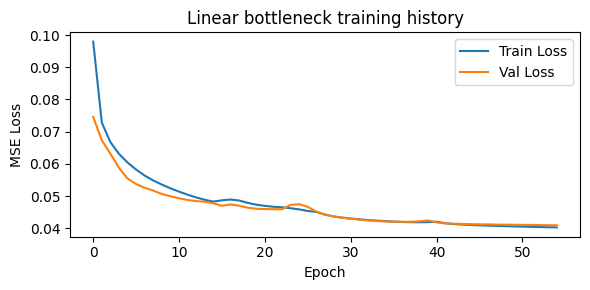

In [72]:
if history is not None:

    # Handle both keras History object and loaded dict
    history_dict = history.history if hasattr(history, 'history') else history

    fig, ax = plt.subplots(figsize=(6, 3))

    ax.set_title('Linear bottleneck training history')
    ax.plot(history_dict['loss'], label='Train Loss')
    ax.plot(history_dict['val_loss'], label='Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 3.5. Anomaly detection

#### 3.5.1. Reconstruction errors 

In [73]:
# Compute reconstruction error on training normals
train_preds = autoencoder.predict(x_train_normals, batch_size=256)
train_mse = np.mean(np.square(x_train_normals - train_preds), axis=(1, 2, 3))

# Compute reconstruction error on test
test_preds = autoencoder.predict(x_test_subset, batch_size=256)
test_mse = np.mean(np.square(x_test_subset - test_preds), axis=(1, 2, 3))
test_mse_df = pd.DataFrame({'mse': test_mse, 'label': list(y_test_binary)})

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


#### 3.5.2. Calibrate detection threshold

In [74]:
thresholds = np.linspace(0.0, 0.015, 50)

result = {
    'threshold': [],
    'balanced_accuracy': []
}

for threshold in thresholds:

    predictions = (test_mse > threshold).astype(int)
    balanced_accuracy = balanced_accuracy_score(y_test_binary, predictions)
    result['threshold'].append(threshold)
    result['balanced_accuracy'].append(balanced_accuracy)

best_idx = np.argmax(result['balanced_accuracy'])
best_threshold = result['threshold'][best_idx]
best_balanced_accuracy = result['balanced_accuracy'][best_idx]
print(f"Best Threshold: {best_threshold:.5f}, Best Balanced Accuracy: {best_balanced_accuracy:.5f}")

Best Threshold: 0.00337, Best Balanced Accuracy: 0.70413


#### 3.5.3. Reconstruction error distributions

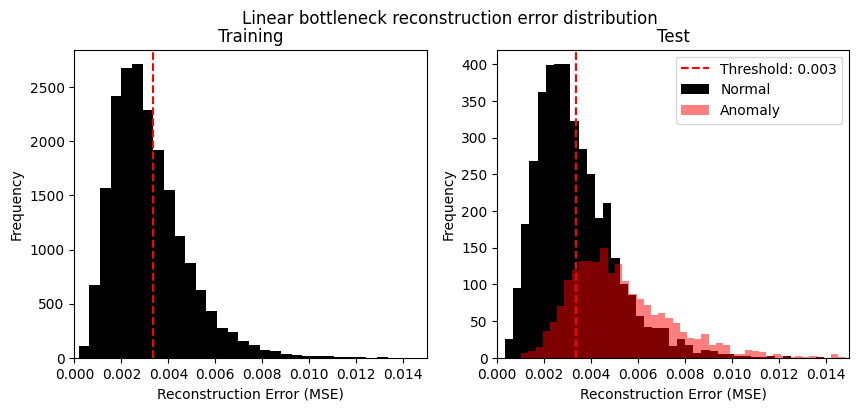

In [75]:
test_mse_df = pd.DataFrame({'mse': test_mse, 'label': list(y_test_binary)})

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Linear bottleneck reconstruction error distribution')

axs[0].hist(train_mse, bins=50, color='black')
axs[0].axvline(best_threshold, color='r', linestyle='--')
axs[0].set_xlim(0, 0.015)
axs[0].set_xlabel('Reconstruction Error (MSE)')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Training')

axs[1].hist(test_mse_df[test_mse_df['label'] == 0]['mse'], bins=50, color='black')
axs[1].hist(test_mse_df[test_mse_df['label'] == 1]['mse'], bins=50, color='red', alpha=0.5)
axs[1].axvline(best_threshold, color='r', linestyle='--')
axs[1].set_xlim(0, 0.015)
axs[1].set_xlabel('Reconstruction Error (MSE)')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Test')
axs[1].legend([f'Threshold: {best_threshold:.3f}','Normal', 'Anomaly'])

plt.show()

### 3.6. Test set evaluation

In [76]:
predictions = (test_mse > best_threshold).astype(int)

accuracy = np.mean(predictions == y_test_binary)
print(f"Test Detection Accuracy: {accuracy*100:.2f}%")

Test Detection Accuracy: 66.65%


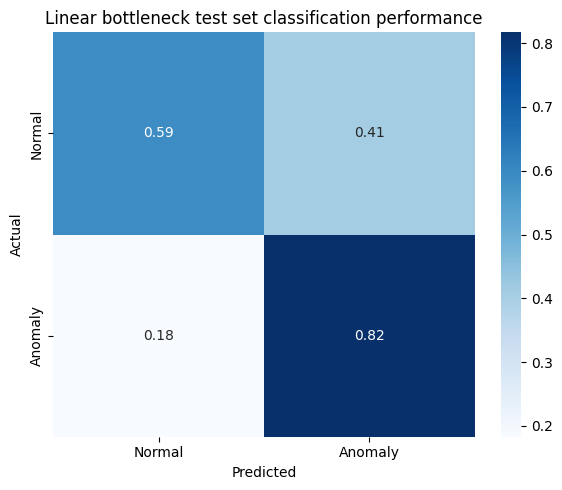

In [77]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title('Linear bottleneck test set classification performance')
cm = confusion_matrix(y_test_binary, predictions, normalize='true')

sns.heatmap(
    cm, 
    annot=True, cmap='Blues', ax=ax,
    xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly']
)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 4. Convolutional bottleneck model

### 4.1. Output paths

In [78]:
model_path   = project_root / 'models' / 'anomaly_conv_bottleneck.keras'
history_path = project_root / 'logs' / 'anomaly_conv_bottleneck' / 'history.json'
log_dir      = project_root / 'logs' / 'anomaly_conv_bottleneck'

log_dir.mkdir(parents=True, exist_ok=True)

print(f'Data will be cached to: {data_path}')
print(f'Model will be saved to: {model_path}')
print(f'History will be saved to: {history_path}')
print(f'Log directory: {log_dir}')

Data will be cached to: /workspaces/autoencoders/data
Model will be saved to: /workspaces/autoencoders/models/anomaly_conv_bottleneck.keras
History will be saved to: /workspaces/autoencoders/logs/anomaly_conv_bottleneck/history.json
Log directory: /workspaces/autoencoders/logs/anomaly_conv_bottleneck


### 4.2. Model definition

In [83]:
def build_conv_bottleneck_model(input_shape=(32, 32, 3), bottleneck_channels=12):
    '''Builds a convolutional autoencoder with a convolutional bottleneck and 
    the specified input shape and number of bottleneck channels.'''

    # Encoder
    encoder_input = Input(shape=input_shape)
    x = encoder_input

    x = Conv2D(32, 3, padding='same', strides=2, name='enc_conv1')(x)
    x = BatchNormalization(name='enc_bn1')(x)
    x = LeakyReLU(0.2, name='enc_relu1')(x)
    
    x = Conv2D(64, 3, padding='same', strides=2, name='enc_conv2')(x)
    x = BatchNormalization(name='enc_bn2')(x)
    x = LeakyReLU(0.2, name='enc_relu2')(x)
    
    # Conv bottleneck: 8x8x64 -> 4x4x12 (4*4*12 = 192 scalars, matching dense vector!)
    latent = Conv2D(bottleneck_channels, 3, padding='same', strides=2, name='conv_latent')(x)
    encoder = Model(encoder_input, latent, name='slim_encoder')

    # Build the decoder
    decoder_input = Input(shape=(4, 4, bottleneck_channels))
    x = decoder_input

    x = Conv2DTranspose(64, 3, padding='same', strides=2, name='dec_conv1')(x)
    x = BatchNormalization(name='dec_bn1')(x)
    x = LeakyReLU(0.2, name='dec_relu1')(x)
    
    x = Conv2DTranspose(32, 3, padding='same', strides=2, name='dec_conv2')(x)
    x = BatchNormalization(name='dec_bn2')(x)
    x = LeakyReLU(0.2, name='dec_relu2')(x)
    
    outputs = Conv2DTranspose(3, 3, padding='same', strides=2, activation='sigmoid', name='dec_output')(x)
    decoder = Model(decoder_input, outputs, name='slim_decoder')

    # Full AE
    ae_output = decoder(encoder(encoder_input))
    autoencoder = Model(encoder_input, ae_output, name='slim_conv_ae')

    return autoencoder, encoder, decoder


In [84]:
# Build the model
autoencoder, encoder, decoder = build_conv_bottleneck_model()

if train_conv_bottleneck:

    # Compile naive model for training
    autoencoder.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=loss
    )

else:

    # Load the pre-trained weights
    autoencoder.load_weights(str(model_path).replace('.keras', '_weights.weights.h5'))

autoencoder.summary()

Model: "slim_conv_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ slim_encoder (Functional)       │ (None, 4, 4, 12)       │        26,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ slim_decoder (Functional)       │ (None, 32, 32, 3)      │        26,691 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,391 (208.56 KB)

 Trainable params: 53,007 (207.06 KB)

 Non-trainable params: 384 (1.50 KB)

### 4.3. Training

In [85]:
training_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=early_stopping_patience,
        min_delta=early_stopping_min_delta,
        restore_best_weights=True,
        verbose=verbose
    ),
    callbacks.ModelCheckpoint(
        filepath=str(model_path).replace('.keras', '_weights.weights.h5'),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=verbose
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=lr_decay,
        patience=lr_patience,
        min_lr=min_lr,
        verbose=verbose
    ),
    callbacks.TensorBoard(
        log_dir=str(log_dir),
        histogram_freq=0
    ),
]

In [86]:
%%time

if train_conv_bottleneck:

    # Train the model
    history = autoencoder.fit(
        x_train_normals, x_train_normals,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=val_split,
        shuffle=True,
        callbacks=training_callbacks,
        verbose=verbose
    )

    # Save the history
    with open(history_path, 'w') as f:
        json.dump(history.history, f)

else:

    # Load training history from disk
    if history_path.exists():
        with open(history_path, 'r') as f:
            history = json.load(f)

    else:
        history = None

print()


CPU times: user 1.86 ms, sys: 1.43 ms, total: 3.29 ms
Wall time: 2.32 ms


### 4.4. Learning curves

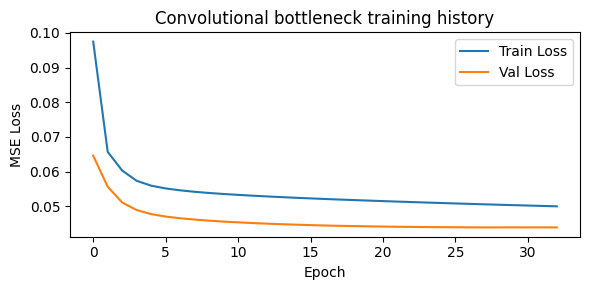

In [87]:
if history is not None:

    # Handle both keras History object and loaded dict
    history_dict = history.history if hasattr(history, 'history') else history

    fig, ax = plt.subplots(figsize=(6, 3))

    ax.set_title('Convolutional bottleneck training history')
    ax.plot(history_dict['loss'], label='Train Loss')
    ax.plot(history_dict['val_loss'], label='Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 4.5. Anomaly detection

#### 4.5.1. Reconstruction errors

In [88]:
# Compute reconstruction error on training normals
train_preds = autoencoder.predict(x_train_normals, batch_size=256)
train_mse = np.mean(np.square(x_train_normals - train_preds), axis=(1, 2, 3))

# Compute reconstruction error on test
test_preds = autoencoder.predict(x_test_subset, batch_size=256)
test_mse = np.mean(np.square(x_test_subset - test_preds), axis=(1, 2, 3))
test_mse_df = pd.DataFrame({'mse': test_mse, 'label': list(y_test_binary)})

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


#### 4.5.2. Detection threshold calibration

In [89]:
thresholds = np.linspace(0.0, 0.015, 50)

result = {
    'threshold': [],
    'balanced_accuracy': []
}

for threshold in thresholds:

    predictions = (test_mse > threshold).astype(int)
    balanced_accuracy = balanced_accuracy_score(y_test_binary, predictions)
    result['threshold'].append(threshold)
    result['balanced_accuracy'].append(balanced_accuracy)

best_idx = np.argmax(result['balanced_accuracy'])
best_threshold = result['threshold'][best_idx]
best_balanced_accuracy = result['balanced_accuracy'][best_idx]
print(f"Best Threshold: {best_threshold:.5f}, Best Balanced Accuracy: {best_balanced_accuracy:.5f}")

Best Threshold: 0.00429, Best Balanced Accuracy: 0.69900


#### 4.5.3. Reconstruction error distributions

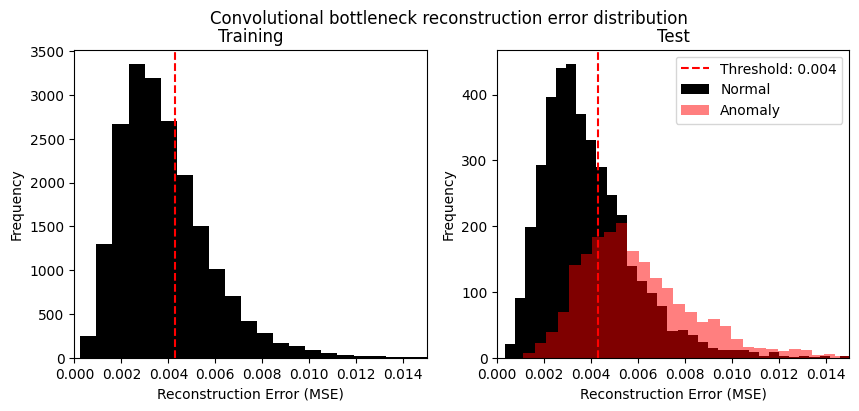

In [90]:
test_mse_df = pd.DataFrame({'mse': test_mse, 'label': list(y_test_binary)})

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Convolutional bottleneck reconstruction error distribution')

axs[0].hist(train_mse, bins=50, color='black')
axs[0].axvline(best_threshold, color='r', linestyle='--')
axs[0].set_xlim(0, 0.015)
axs[0].set_xlabel('Reconstruction Error (MSE)')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Training')

axs[1].hist(test_mse_df[test_mse_df['label'] == 0]['mse'], bins=50, color='black')
axs[1].hist(test_mse_df[test_mse_df['label'] == 1]['mse'], bins=50, color='red', alpha=0.5)
axs[1].axvline(best_threshold, color='r', linestyle='--')
axs[1].set_xlim(0, 0.015)
axs[1].set_xlabel('Reconstruction Error (MSE)')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Test')
axs[1].legend([f'Threshold: {best_threshold:.3f}','Normal', 'Anomaly'])

plt.show()

### 4.6. Test set evaluation

In [91]:
predictions = (test_mse > best_threshold).astype(int)

accuracy = np.mean(predictions == y_test_binary)
print(f"Test Detection Accuracy: {accuracy*100:.2f}%")

Test Detection Accuracy: 68.50%


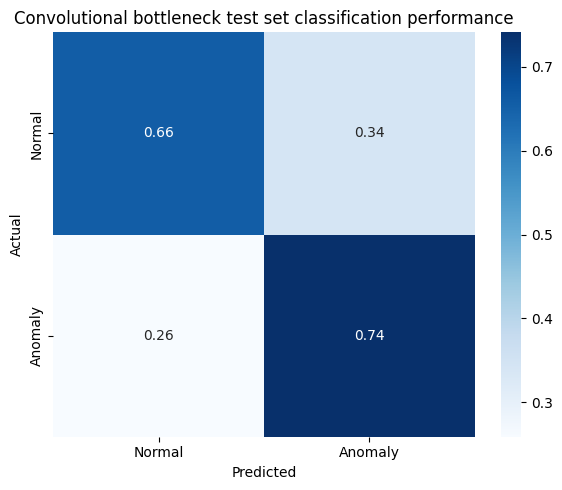

In [92]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title('Convolutional bottleneck test set classification performance')
cm = confusion_matrix(y_test_binary, predictions, normalize='true')

sns.heatmap(
    cm, 
    annot=True, cmap='Blues', ax=ax,
    xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly']
)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 5. Variational bottleneck model

### 5.1. Output paths

In [93]:
model_path   = project_root / 'models' / 'anomaly_var_bottleneck.keras'
history_path = project_root / 'logs' / 'anomaly_var_bottleneck' / 'history.json'
log_dir      = project_root / 'logs' / 'anomaly_var_bottleneck'

log_dir.mkdir(parents=True, exist_ok=True)

print(f'Data will be cached to: {data_path}')
print(f'Model will be saved to: {model_path}')
print(f'History will be saved to: {history_path}')
print(f'Log directory: {log_dir}')

Data will be cached to: /workspaces/autoencoders/data
Model will be saved to: /workspaces/autoencoders/models/anomaly_var_bottleneck.keras
History will be saved to: /workspaces/autoencoders/logs/anomaly_var_bottleneck/history.json
Log directory: /workspaces/autoencoders/logs/anomaly_var_bottleneck


### 5.2. Model definition

In [94]:
import keras
from keras import ops
from keras.layers import Layer, Input, Conv2D, BatchNormalization, LeakyReLU, Flatten, Dense, Reshape, Conv2DTranspose
from keras.models import Model

# 1. Update your Sampling layer to use Keras 3 operations
class Sampling(Layer):
    '''Reparameterization trick: z = mean + exp(0.5 * log_var) * epsilon'''

    def call(self, inputs):
        z_mean, z_log_var = inputs
        shape = ops.shape(z_mean)
        epsilon = keras.random.normal(shape=shape)

        return z_mean + ops.exp(0.5 * z_log_var) * epsilon


class KLLossLayer(Layer):
    '''Activity regularization layer to cleanly inject KL loss into Functional API'''

    def __init__(self, kl_weight=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.kl_weight = kl_weight

    def call(self, inputs):
        z_mean, z_log_var = inputs

        kl_loss = -0.5 * ops.mean(
            ops.sum(1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var), axis=1)
        )
        
        self.add_loss(self.kl_weight * kl_loss)
        #self.add_metric(kl_loss)
        
        return z_mean


def build_var_bottleneck_model(input_shape=(32, 32, 3), bottleneck_channels=12, kl_weight=1e-4):
    '''Builds a convolutional VAE using the Functional API with add_loss().'''

    # Encoder
    encoder_input = Input(shape=input_shape)
    x = encoder_input

    x = Conv2D(32, 3, padding='same', strides=2, name='enc_conv1')(x)
    x = BatchNormalization(name='enc_bn1')(x)
    x = LeakyReLU(0.2, name='enc_relu1')(x)
    
    x = Conv2D(64, 3, padding='same', strides=2, name='enc_conv2')(x)
    x = BatchNormalization(name='enc_bn2')(x)
    x = LeakyReLU(0.2, name='enc_relu2')(x)
    
    # Spatial feature bottleneck: 8x8x64 -> 4x4x12 (192 values total)
    spatial_latent = Conv2D(bottleneck_channels, 3, padding='same', strides=2, name='enc_conv_latent')(x)
    
    # Flatten spatial tensor to vector for distribution parameters
    flat_dim = 4 * 4 * bottleneck_channels
    flat = Flatten(name='flatten_latent')(spatial_latent)
    
    z_mean = Dense(flat_dim, name='z_mean')(flat)
    z_log_var = Dense(flat_dim, name='z_log_var')(flat)
    
    # Trigger the KL loss using our custom layer
    KLLossLayer(kl_weight=kl_weight, name='kl_loss_trig')([z_mean, z_log_var])
    
    z = Sampling(name='z_sampling')([z_mean, z_log_var])
    
    # Reshape back to spatial dimensions for the convolutional decoder
    z_reshaped = Reshape((4, 4, bottleneck_channels), name='z_reshape')(z)
    
    # Expose a model that outputs latent mean for downstream clustering/IF
    encoder_mean = Model(encoder_input, z_mean, name='encoder_mean')

    # Build the decoder
    decoder_input = Input(shape=(4, 4, bottleneck_channels), name='decoder_input')
    d = decoder_input

    d = Conv2DTranspose(64, 3, padding='same', strides=2, name='dec_conv1')(d)
    d = BatchNormalization(name='dec_bn1')(d)
    d = LeakyReLU(0.2, name='dec_relu1')(d)
    
    d = Conv2DTranspose(32, 3, padding='same', strides=2, name='dec_conv2')(d)
    d = BatchNormalization(name='dec_bn2')(d)
    d = LeakyReLU(0.2, name='dec_relu2')(d)
    
    outputs = Conv2DTranspose(3, 3, padding='same', strides=2, activation='sigmoid', name='dec_output')(d)
    decoder = Model(decoder_input, outputs, name='slim_decoder')

    # Full VAE graph
    ae_output = decoder(z_reshaped)
    autoencoder = Model(encoder_input, ae_output, name='conv_vae')


    return autoencoder, encoder_mean, decoder

In [95]:
# Build the model
autoencoder, encoder_mean, decoder = build_var_bottleneck_model()

if train_var_bottleneck:

    # Compile naive model for training
    autoencoder.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=loss
    )

else:

    # Load the pre-trained weights
    autoencoder.load_weights(str(model_path).replace('.keras', '_weights.weights.h5'))

autoencoder.summary()

Model: "conv_vae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv1 (Conv2D)  │ (None, 16, 16,    │        896 │ input_layer_13[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn1             │ (None, 16, 16,    │        128 │ enc_conv1[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_relu1           │ (None, 16, 16,    │          0 │ enc_bn1[0][0]     │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv2 (Conv2D)  │ (None, 8, 8, 64)  │     18,496 │ enc_relu1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn2             │ (None, 8, 8, 64)  │        256 │ enc_conv2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_relu2           │ (None, 8, 8, 64)  │          0 │ enc_bn2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv_latent     │ (None, 4, 4, 12)  │      6,924 │ enc_relu2[0][0]   │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_latent      │ (None, 192)       │          0 │ enc_conv_latent[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 192)       │     37,056 │ flatten_latent[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 192)       │     37,056 │ flatten_latent[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sampling          │ (None, 192)       │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_reshape (Reshape) │ (None, 4, 4, 12)  │          0 │ z_sampling[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slim_decoder        │ (None, 32, 32, 3) │     26,691 │ z_reshape[0][0]   │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 127,503 (498.06 KB)

 Trainable params: 127,119 (496.56 KB)

 Non-trainable params: 384 (1.50 KB)

### 5.3. Training

In [96]:
training_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=early_stopping_patience,
        min_delta=early_stopping_min_delta,
        restore_best_weights=True,
        verbose=verbose
    ),
    callbacks.ModelCheckpoint(
        filepath=str(model_path).replace('.keras', '_weights.weights.h5'),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=verbose
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=lr_decay,
        patience=lr_patience,
        min_lr=min_lr,
        verbose=verbose
    ),
    callbacks.TensorBoard(
        log_dir=str(log_dir),
        histogram_freq=0
    ),
]

In [97]:
%%time

if train_var_bottleneck:

    # Train the model
    history = autoencoder.fit(
        x_train_normals, x_train_normals,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=val_split,
        shuffle=True,
        callbacks=training_callbacks,
        verbose=verbose
    )

    # Save the history
    with open(history_path, 'w') as f:
        json.dump(history.history, f)

else:

    # Load training history from disk
    if history_path.exists():
        with open(history_path, 'r') as f:
            history = json.load(f)

    else:
        history = None

print()


CPU times: user 1.13 ms, sys: 1.77 ms, total: 2.89 ms
Wall time: 2.15 ms


### 5.4. Learning curves

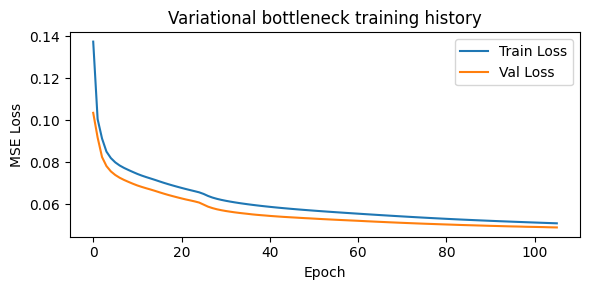

In [98]:
if history is not None:

    # Handle both keras History object and loaded dict
    history_dict = history.history if hasattr(history, 'history') else history

    fig, ax = plt.subplots(figsize=(6, 3))

    ax.set_title('Variational bottleneck training history')
    ax.plot(history_dict['loss'], label='Train Loss')
    ax.plot(history_dict['val_loss'], label='Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 5.5. Anomaly detection

#### 5.5.1. Reconstruction error

In [99]:
# Compute reconstruction error on training normals
train_preds = autoencoder.predict(x_train_normals, batch_size=256)
train_mse = np.mean(np.square(x_train_normals - train_preds), axis=(1, 2, 3))

# Compute reconstruction error on test
test_preds = autoencoder.predict(x_test_subset, batch_size=256)
test_mse = np.mean(np.square(x_test_subset - test_preds), axis=(1, 2, 3))
test_mse_df = pd.DataFrame({'mse': test_mse, 'label': list(y_test_binary)})

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step


#### 5.5.2. Calibrate detection threshold

In [100]:
thresholds = np.linspace(0.0, 0.015, 50)

result = {
    'threshold': [],
    'balanced_accuracy': []
}

for threshold in thresholds:

    predictions = (test_mse > threshold).astype(int)
    balanced_accuracy = balanced_accuracy_score(y_test_binary, predictions)
    result['threshold'].append(threshold)
    result['balanced_accuracy'].append(balanced_accuracy)

best_idx = np.argmax(result['balanced_accuracy'])
best_threshold = result['threshold'][best_idx]
best_balanced_accuracy = result['balanced_accuracy'][best_idx]
print(f"Best Threshold: {best_threshold:.5f}, Best Balanced Accuracy: {best_balanced_accuracy:.5f}")

Best Threshold: 0.00520, Best Balanced Accuracy: 0.70538


#### 5.5.3. Reconstruction error distributions

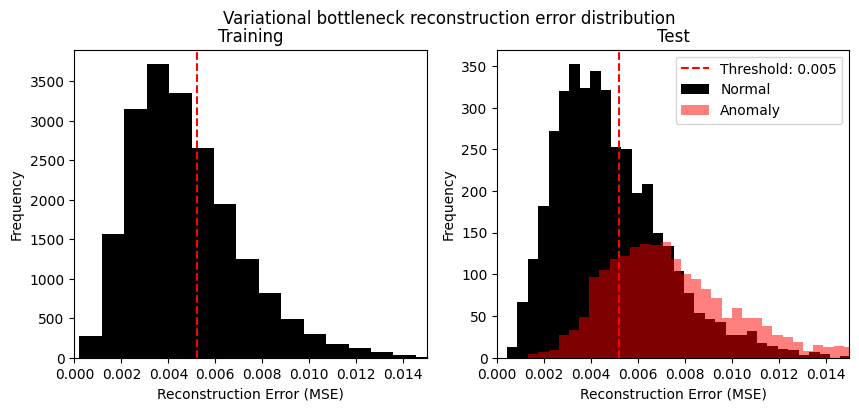

In [101]:
test_mse_df = pd.DataFrame({'mse': test_mse, 'label': list(y_test_binary)})

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Variational bottleneck reconstruction error distribution')

axs[0].hist(train_mse, bins=50, color='black')
axs[0].axvline(best_threshold, color='r', linestyle='--')
axs[0].set_xlim(0, 0.015)
axs[0].set_xlabel('Reconstruction Error (MSE)')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Training')

axs[1].hist(test_mse_df[test_mse_df['label'] == 0]['mse'], bins=50, color='black')
axs[1].hist(test_mse_df[test_mse_df['label'] == 1]['mse'], bins=50, color='red', alpha=0.5)
axs[1].axvline(best_threshold, color='r', linestyle='--')
axs[1].set_xlim(0, 0.015)
axs[1].set_xlabel('Reconstruction Error (MSE)')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Test')
axs[1].legend([f'Threshold: {best_threshold:.3f}','Normal', 'Anomaly'])

plt.show()

### 5.6. Test set evaluation

In [102]:
predictions = (test_mse > best_threshold).astype(int)

accuracy = np.mean(predictions == y_test_binary)
print(f"Test Detection Accuracy: {accuracy*100:.2f}%")

Test Detection Accuracy: 68.05%


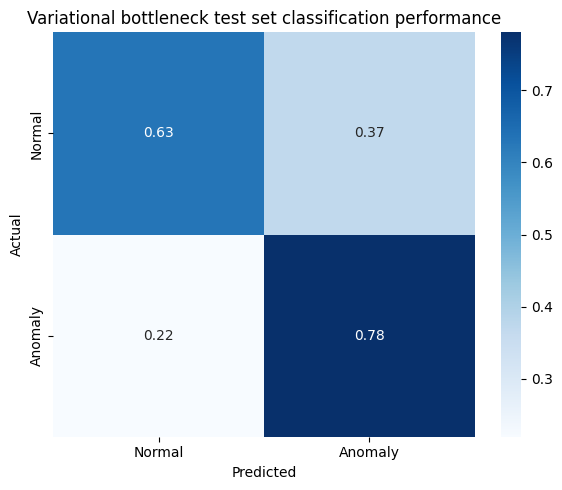

In [103]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_title('Variational bottleneck test set classification performance')
cm = confusion_matrix(y_test_binary, predictions, normalize='true')

sns.heatmap(
    cm, 
    annot=True, cmap='Blues', ax=ax,
    xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly']
)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()